# U22 — Big Data: Kafka & Spark — Lab

### Real-world brief: processing a factory's high-volume sensor streams

A smart factory's 24 machines emit a torrent of sensor events and readings — too much to handle on one process the old way. This lab has two halves that mirror a modern big-data stack:

- **Part A — Kafka.** You'll build a small **partitioned, append-only event log** from scratch to *feel* how Kafka works: partitions, keys, offsets, ordering and replay. (A real broker isn't needed to learn the model.)
- **Part B — Spark.** You'll run **real Apache Spark** in local mode over a 120k-row readings file: lazy transformations vs actions, `groupBy` aggregations, window functions and partitioning.

**Resources provided:** `factory_events.csv` (≈30k events to replay) and `sensor_readings_big.csv` (≈120k readings for Spark).

_Phase F — Data Engineering._

#objectives

Model a Kafka topic: partitions, key-based routing, offsets

Consume with offset tracking, consumer groups and replay

Run Spark in local mode and read a large dataset

Distinguish lazy transformations from actions; read a query plan

Aggregate with groupBy, compute window metrics, and control partitioning

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom. Part B needs `pyspark` (the setup cell installs it if missing — works in Colab).

In [1]:
# === SETUP: build the source files if missing ===
import os
import numpy as np
import pandas as pd


def build_factory(events_path="factory_events.csv", readings_path="sensor_readings_big.csv",
                  seed=222, verbose=False):
    """Two datasets for the Big Data lab (U22):

      factory_events.csv      ~30k discrete sensor EVENTS to replay through a mini event log
                              (Kafka model): event_id, ts, machine_id, sensor, value, severity.
      sensor_readings_big.csv ~120k time-series READINGS for distributed processing with Spark:
                              ts, machine_id, line, temp_c, vibration_mm_s, pressure_bar,
                              throughput_units, status.
    """
    rng = np.random.default_rng(seed)
    machines = [f"M{i:03d}" for i in range(1, 25)]      # 24 machines
    lines = {m: f"LINE_{(i % 4) + 1}" for i, m in enumerate(machines)}

    # ---- discrete events stream ----
    NE = 30000
    ev_machine = rng.choice(machines, NE)
    sensors = rng.choice(["temp", "vibration", "pressure", "current"], NE, p=[0.3, 0.3, 0.2, 0.2])
    base = {"temp": 65, "vibration": 2.5, "pressure": 6.0, "current": 30}
    sd = {"temp": 8, "vibration": 1.0, "pressure": 0.8, "current": 5}
    value = np.array([rng.normal(base[s], sd[s]) for s in sensors]).round(2)
    # severity from how extreme the value is
    z = np.array([(v - base[s]) / sd[s] for v, s in zip(value, sensors)])
    severity = np.where(np.abs(z) > 2.5, "critical", np.where(np.abs(z) > 1.5, "warning", "info"))
    t0 = pd.Timestamp("2024-06-01")
    ts = t0 + pd.to_timedelta(np.sort(rng.uniform(0, 7 * 24 * 3600, NE)), unit="s")
    events = pd.DataFrame({
        "event_id": np.arange(NE), "ts": ts, "machine_id": ev_machine,
        "sensor": sensors, "value": value, "severity": severity,
    })
    events.to_csv(events_path, index=False)

    # ---- large time-series readings for Spark ----
    NR = 120000
    rmachine = rng.choice(machines, NR)
    rline = np.array([lines[m] for m in rmachine])
    # machine-specific health: a few machines run hot / shake more
    hot = {m: rng.normal(0, 1) for m in machines}
    temp = np.array([rng.normal(65 + 6 * hot[m], 7) for m in rmachine]).round(2)
    vib = np.clip(np.array([rng.normal(2.5 + 0.8 * hot[m], 0.9) for m in rmachine]), 0, None).round(3)
    pres = np.clip(rng.normal(6.0, 0.7, NR), 0, None).round(2)
    thru = np.clip(rng.normal(95, 18, NR), 0, None).round(0)
    status = np.where(vib > 4.5, "fault", np.where(vib > 3.5, "warn", "ok"))
    rts = pd.Timestamp("2024-06-01") + pd.to_timedelta(rng.uniform(0, 7 * 24 * 3600, NR), unit="s")
    readings = pd.DataFrame({
        "ts": rts.round("s"), "machine_id": rmachine, "line": rline,
        "temp_c": temp, "vibration_mm_s": vib, "pressure_bar": pres,
        "throughput_units": thru, "status": status,
    }).sort_values("ts").reset_index(drop=True)
    readings.to_csv(readings_path, index=False)

    if verbose:
        print("events:", events.shape, "| severity mix:", events.severity.value_counts().to_dict())
        print("readings:", readings.shape, "| status mix:", readings.status.value_counts().to_dict())
        print("machines:", len(machines), "| lines: 4")
    return events, readings

if not (os.path.exists('factory_events.csv') and os.path.exists('sensor_readings_big.csv')):
    build_factory(); print('Generated source files.')
else:
    print('Found the provided source files.')

Generated source files.


In [2]:
import pandas as pd, numpy as np
events = pd.read_csv('factory_events.csv', parse_dates=['ts'])
print('events:', events.shape)
events.head(3)

events: (30000, 6)


,event_id,ts,machine_id,sensor,value,severity
0,0,2024-06-01 00:00:05.281632925,M010,vibration,3.08,info
1,1,2024-06-01 00:01:13.375520263,M010,temp,66.75,info
2,2,2024-06-01 00:01:29.525385871,M009,current,26.84,info


# Part A — Kafka: a partitioned event log
Kafka is, at heart, a **distributed append-only log split into partitions**. Producers append records; each record's **key** decides its partition (so all events for one machine stay ordered together); consumers read sequentially and track their position with an **offset**. We'll build a tiny version to make those ideas concrete.

In [4]:
# -----------------------------------------------------------
# 🔹 A1. A MINI TOPIC — append-only log with key-based partitioning
# -----------------------------------------------------------
import zlib

class Topic:
    def __init__(self, name, num_partitions=4):
        self.name = name; self.num_partitions = num_partitions
        self.partitions = [[] for _ in range(num_partitions)]   # each = list of records
    def _route(self, key):
        # stable hash of the key -> partition (same key always same partition => ordering)
        return zlib.crc32(str(key).encode()) % self.num_partitions
    def produce(self, key, value):
        p = self._route(key)
        offset = len(self.partitions[p])
        self.partitions[p].append({'offset': offset, 'key': key, 'value': value})
        return p, offset
    def sizes(self):
        return [len(p) for p in self.partitions]

topic = Topic('machine-events', num_partitions=4)
print('created topic with', topic.num_partitions, 'partitions')

created topic with 4 partitions


In [5]:
# -----------------------------------------------------------
# 🔹 A2. PRODUCE events into the log, keyed by machine_id
# -----------------------------------------------------------
for r in events.itertuples(index=False):
    topic.produce(key=r.machine_id, value={'sensor': r.sensor, 'value': r.value, 'severity': r.severity})
print('records per partition:', topic.sizes(), '-> total', sum(topic.sizes()))
# verify a key maps to exactly one partition (per-key ordering guarantee)
import collections
where = collections.defaultdict(set)
for pi, part in enumerate(topic.partitions):
    for rec in part: where[rec['key']].add(pi)
multi = {k: v for k, v in where.items() if len(v) > 1}
print('machines spread across >1 partition:', len(multi), '(should be 0 -> ordering preserved per machine)')

records per partition: [7528, 8688, 6291, 7493] -> total 30000
machines spread across >1 partition: 0 (should be 0 -> ordering preserved per machine)


In [6]:
# -----------------------------------------------------------
# 🔹 A3. A CONSUMER that tracks offsets (and can replay)
# -----------------------------------------------------------
class Consumer:
    def __init__(self, topic, group):
        self.topic = topic; self.group = group
        self.offsets = {p: 0 for p in range(topic.num_partitions)}   # committed position
    def poll(self, partition, max_records=5):
        start = self.offsets[partition]
        batch = self.topic.partitions[partition][start:start + max_records]
        return batch
    def commit(self, partition, n):
        self.offsets[partition] += n
    def seek(self, partition, offset):
        self.offsets[partition] = offset      # replay: rewind to an earlier offset

c = Consumer(topic, group='analytics')
batch = c.poll(0, max_records=3)
print('first 3 records of partition 0:')
for rec in batch: print(' ', rec['offset'], rec['key'], rec['value'])
c.commit(0, len(batch))
print('committed offset for partition 0 is now:', c.offsets[0])

first 3 records of partition 0:
  0 M018 {'sensor': 'temp', 'value': 68.08, 'severity': 'info'}
  1 M007 {'sensor': 'pressure', 'value': 5.92, 'severity': 'info'}
  2 M013 {'sensor': 'vibration', 'value': 2.84, 'severity': 'info'}
committed offset for partition 0 is now: 3


#### 🧪 EXERCISE 1 — Partition count changes the spread
1. Rebuild the topic with `num_partitions=8`, re-produce all events, and print the per-partition sizes.
2. In a comment, explain the trade-off: more partitions = more parallelism for consumers, but also more overhead and weaker global ordering (ordering is only guaranteed *within* a partition).

In [8]:
topic = Topic('machine-events', num_partitions=8)
for r in events.itertuples(index=False):
    topic.produce(key=r.machine_id, value={'sensor': r.sensor, 'value': r.value, 'severity': r.severity})
print('records per partition (8 partitions):', topic.sizes(), '-> total', sum(topic.sizes()))

# 2. partition-count trade-off: More partitions allow for greater parallelism, as more consumers can process data concurrently.
#    However, it also introduces more overhead (e.g., managing more partitions) and can weaken global ordering guarantees,
#    as ordering is only maintained within a single partition, not across the entire topic.

records per partition (8 partitions): [5005, 5005, 2539, 2525, 2523, 3683, 3752, 4968] -> total 30000


#### 🧪 EXERCISE 2 — Consumer groups & replay
1. Drain partition 0 fully with one consumer (poll+commit in a loop until empty); print how many records it read.
2. Create a **second** consumer in a different group, `seek(0, 0)` to rewind, and confirm it can **replay** the same records from the start — independent groups have independent offsets.
3. In a comment, give one real use of replay (e.g. reprocessing after a bug fix).

In [9]:
# 1. Drain partition 0 fully with one consumer
records_read = 0
while True:
    batch = c.poll(0, max_records=10) # Poll up to 10 records at a time
    if not batch:
        break # No more records in this partition
    records_read += len(batch)
    c.commit(0, len(batch))
print(f"Consumer 'analytics' drained partition 0, reading {records_read} records.")

# 2. Create a second consumer in a different group, rewind, and confirm replay
consumer_replay = Consumer(topic, group='replay-group')
consumer_replay.seek(0, 0) # Rewind partition 0 to offset 0
print("\nSecond consumer 'replay-group' seeking partition 0 to offset 0.")

# Poll and print first few records from the replayed partition to confirm
replay_batch = consumer_replay.poll(0, max_records=3)
print('First 3 replayed records from partition 0:')
for rec in replay_batch: print(' ', rec['offset'], rec['key'], rec['value'])

# 3. a real use of replay:
#    A real use of replay is for disaster recovery or debugging. For example, if a bug is found in a consumer's processing logic,
#    the consumer can be rewound to an earlier offset (or the beginning of the topic) and reprocess the messages with the fixed logic.
#    This ensures data consistency and allows for historical data recalculations without data loss.

Consumer 'analytics' drained partition 0, reading 7525 records.

Second consumer 'replay-group' seeking partition 0 to offset 0.
First 3 replayed records from partition 0:
  0 M018 {'sensor': 'temp', 'value': 68.08, 'severity': 'info'}
  1 M007 {'sensor': 'pressure', 'value': 5.92, 'severity': 'info'}
  2 M013 {'sensor': 'vibration', 'value': 2.84, 'severity': 'info'}


# Part B — Spark: distributed processing
When data outgrows one machine, **Spark** spreads it across partitions and processes them in parallel. Two ideas to hold onto: **transformations are lazy** (they just build a plan) and **actions trigger execution**; and **partitions** are the unit of parallelism.

In [10]:
# -----------------------------------------------------------
# 🔹 B1. START SPARK (local mode) and read the big file
# In Colab, uncomment the next line to install Spark:
# !pip install pyspark -q
# -----------------------------------------------------------
import os
os.environ['PYSPARK_PYTHON'] = 'python3'
from pyspark.sql import SparkSession, functions as F, Window
spark = (SparkSession.builder.master('local[*]').appName('factory')
         .config('spark.ui.enabled', 'false').config('spark.sql.shuffle.partitions', '8')
         .getOrCreate())
spark.sparkContext.setLogLevel('ERROR')
df = spark.read.csv('sensor_readings_big.csv', header=True, inferSchema=True)
print('rows:', df.count(), '| partitions:', df.rdd.getNumPartitions())
df.printSchema()

rows: 120000 | partitions: 2
root
 |-- ts: timestamp (nullable = true)
 |-- machine_id: string (nullable = true)
 |-- line: string (nullable = true)
 |-- temp_c: double (nullable = true)
 |-- vibration_mm_s: double (nullable = true)
 |-- pressure_bar: double (nullable = true)
 |-- throughput_units: double (nullable = true)
 |-- status: string (nullable = true)



In [12]:
# -----------------------------------------------------------
# 🔹 B2. LAZY vs ACTION — transformations build a plan; actions run it
# -----------------------------------------------------------
hot = df.filter(df.temp_c > 75).select('machine_id', 'line', 'temp_c', 'vibration_mm_s')  # lazy
print('No work has happened yet — `hot` is just a plan. Here it is:')
hot.explain()                       # show the physical plan (still no data processed)
print('\nNow an ACTION (count) triggers execution:')
print('hot rows:', hot.count())     # action -> Spark actually runs the job

No work has happened yet — `hot` is just a plan. Here it is:
== Physical Plan ==
*(1) Filter (isnotnull(temp_c#20) AND (temp_c#20 > 75.0))
+- FileScan csv [machine_id#18,line#19,temp_c#20,vibration_mm_s#21] Batched: false, DataFilters: [isnotnull(temp_c#20), (temp_c#20 > 75.0)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/content/sensor_readings_big.csv], PartitionFilters: [], PushedFilters: [IsNotNull(temp_c), GreaterThan(temp_c,75.0)], ReadSchema: struct<machine_id:string,line:string,temp_c:double,vibration_mm_s:double>



Now an ACTION (count) triggers execution:
hot rows: 17095


In [13]:
# -----------------------------------------------------------
# 🔹 B3. GROUP-BY AGGREGATION — per-machine health summary
# -----------------------------------------------------------
summary = (df.groupBy('machine_id')
           .agg(F.round(F.avg('temp_c'), 1).alias('avg_temp'),
                F.round(F.avg('vibration_mm_s'), 2).alias('avg_vib'),
                F.round(F.max('vibration_mm_s'), 2).alias('max_vib'),
                F.sum(F.when(df.status == 'fault', 1).otherwise(0)).alias('fault_events'),
                F.count('*').alias('readings'))
           .orderBy(F.desc('fault_events')))
summary.show(8)

+----------+--------+-------+-------+------------+--------+
|machine_id|avg_temp|avg_vib|max_vib|fault_events|readings|
+----------+--------+-------+-------+------------+--------+
|      M004|    75.7|   3.93|   7.15|        1307|    5021|
|      M006|    73.4|   3.58|   6.78|         801|    5019|
|      M008|    72.7|   3.49|   6.82|         665|    4970|
|      M018|    71.4|   3.39|   6.75|         541|    4987|
|      M009|    70.1|   3.22|   6.05|         396|    4951|
|      M021|    69.7|   3.14|   6.57|         327|    5051|
|      M007|    69.6|   3.12|   6.17|         317|    5026|
|      M010|    68.4|   2.97|   6.71|         207|    5019|
+----------+--------+-------+-------+------------+--------+
only showing top 8 rows


In [14]:
# -----------------------------------------------------------
# 🔹 B4. WINDOW FUNCTION — rolling average vibration per machine over time
# -----------------------------------------------------------
w = Window.partitionBy('machine_id').orderBy('ts').rowsBetween(-4, 0)
rolled = (df.withColumn('vib_rolling5', F.round(F.avg('vibration_mm_s').over(w), 3))
          .select('machine_id', 'ts', 'vibration_mm_s', 'vib_rolling5'))
rolled.orderBy('machine_id', 'ts').show(6)
print('Each row now carries a 5-reading rolling average within its machine — a classic streaming metric.')

+----------+-------------------+--------------+------------+
|machine_id|                 ts|vibration_mm_s|vib_rolling5|
+----------+-------------------+--------------+------------+
|      M001|2024-06-01 00:02:08|         2.637|       2.637|
|      M001|2024-06-01 00:03:40|         1.014|       1.826|
|      M001|2024-06-01 00:04:10|           0.0|       1.217|
|      M001|2024-06-01 00:04:16|         2.197|       1.462|
|      M001|2024-06-01 00:05:28|          1.04|       1.378|
|      M001|2024-06-01 00:06:56|         0.552|       0.961|
+----------+-------------------+--------------+------------+
only showing top 6 rows
Each row now carries a 5-reading rolling average within its machine — a classic streaming metric.


#### 🧪 EXERCISE 3 — Find the problem machines
1. Using `summary` (or a fresh aggregation), find the **top 5 machines by fault rate** (`fault_events / readings`). Show machine_id and the rate.
2. In a comment, explain why doing this in Spark scales to billions of rows where pandas would run out of memory.

In [15]:
# 1. top-5 machines by fault rate
(summary.withColumn('fault_rate', F.col('fault_events') / F.col('readings'))
        .orderBy(F.desc('fault_rate'))
        .select('machine_id', 'fault_rate')
        .show(5))

# 2. why Spark scales where pandas can't:
#    Spark scales to billions of rows by distributing data and computations across a cluster of machines.
#    Instead of loading the entire dataset into the memory of a single machine (like pandas does),
#    Spark partitions the data and processes each partition independently and in parallel.
#    This allows Spark to handle datasets much larger than the memory capacity of any single machine.
#    Pandas, on the other hand, operates on data held entirely in RAM on a single machine, which quickly becomes a bottleneck
#    and leads to out-of-memory errors when dealing with 'big data'.

+----------+-------------------+
|machine_id|         fault_rate|
+----------+-------------------+
|      M004|0.26030671181039633|
|      M006|0.15959354453078303|
|      M008|0.13380281690140844|
|      M018|0.10848205333868056|
|      M009| 0.0799838416481519|
+----------+-------------------+
only showing top 5 rows


In [16]:
# -----------------------------------------------------------
# 🔹 B5. PARTITIONING — the unit of parallelism; write partitioned output
# -----------------------------------------------------------
print('current partitions:', df.rdd.getNumPartitions())
by_line = df.repartition('line')          # reshuffle so each line's data is grouped
print('after repartition by line:', by_line.rdd.getNumPartitions())
# write partitioned parquet — a common 'load' step that makes later reads fast
(df.write.mode('overwrite').partitionBy('line')
   .parquet('readings_by_line.parquet'))
print('wrote partitioned parquet. Folders created:')
print([p for p in os.listdir('readings_by_line.parquet') if p.startswith('line=')])

current partitions: 2
after repartition by line: 2
wrote partitioned parquet. Folders created:
['line=LINE_2', 'line=LINE_3', 'line=LINE_1', 'line=LINE_4']


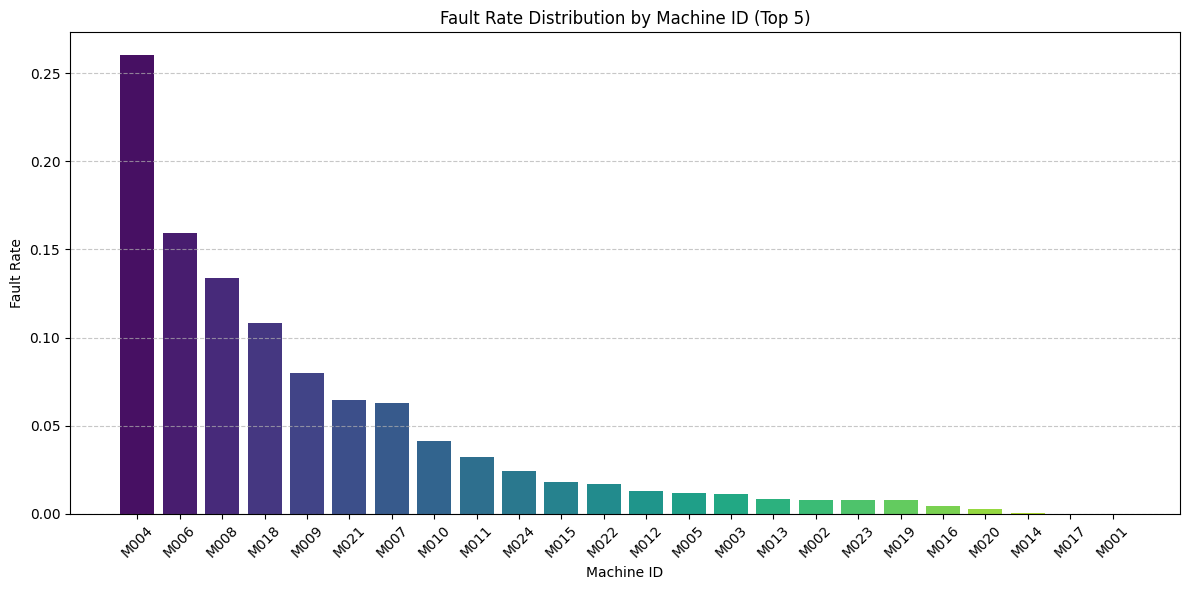

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pyspark.sql import SparkSession, functions as F, Window

# Re-initialize Spark session if it's not active
if 'spark' not in locals() or spark._jsc is None or spark._jsc.sc().isStopped():
    spark = (SparkSession.builder.master('local[*]').appName('factory')
             .config('spark.ui.enabled', 'false').config('spark.sql.shuffle.partitions', '8')
             .getOrCreate())
    spark.sparkContext.setLogLevel('ERROR')
    # Re-load df and summary if Spark session was re-initialized
    df = spark.read.csv('sensor_readings_big.csv', header=True, inferSchema=True)
    summary = (df.groupBy('machine_id')
               .agg(F.round(F.avg('temp_c'), 1).alias('avg_temp'),
                    F.round(F.avg('vibration_mm_s'), 2).alias('avg_vib'),
                    F.round(F.max('vibration_mm_s'), 2).alias('max_vib'),
                    F.sum(F.when(df.status == 'fault', 1).otherwise(0)).alias('fault_events'),
                    F.count('*').alias('readings'))
               .orderBy(F.desc('fault_events')))

fault_rate_df = summary.withColumn('fault_rate', F.col('fault_events') / F.col('readings')) \
                        .select('machine_id', 'fault_rate') \
                        .orderBy(F.desc('fault_rate')).toPandas()

plt.figure(figsize=(12, 6))
plt.bar(x=fault_rate_df['machine_id'], height=fault_rate_df['fault_rate'], color=sns.color_palette('viridis', len(fault_rate_df)))
plt.title('Fault Rate Distribution by Machine ID (Top 5)')
plt.xlabel('Machine ID')
plt.ylabel('Fault Rate')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 🧪 EXERCISE 4 — Partitioned reads & quantiles
1. Read back just one line's data from `readings_by_line.parquet` (path `.../line=LINE_1`) and count its rows — note you didn't have to scan the other lines (partition pruning).
2. Use `df.approxQuantile('temp_c', [0.5, 0.95, 0.99], 0.01)` to get approximate percentiles, and say in a comment why Spark uses *approximate* quantiles on big data.

In [23]:
# 1. partitioned read of one line; approximate quantiles
line1_df = spark.read.parquet('readings_by_line.parquet/line=LINE_1')
print(f"Rows for LINE_1: {line1_df.count()}")

# 2. Use approxQuantile to get approximate percentiles
quantiles = df.approxQuantile('temp_c', [0.5, 0.95, 0.99], 0.01)
print(f"Approximate quantiles for temp_c (median, 95th, 99th percentile): {quantiles}")

# 2. why approximate quantiles at scale:
#    Spark uses approximate quantiles for large datasets because calculating exact quantiles
#    requires sorting the entire dataset, which is a very expensive operation in a distributed environment.
#    For very large datasets, sorting can be computationally prohibitive and memory-intensive.
#    Approximate quantiles provide a good balance between accuracy and performance,
#    allowing Spark to estimate percentiles with a specified relative error (e.g., 0.01) much faster
#    by using algorithms like T-Digest or Greenwald-Khanna.
#    These algorithms work by summarizing the data distribution without needing to store or sort all individual data points.

Rows for LINE_1: 29973
Approximate quantiles for temp_c (median, 95th, 99th percentile): [65.7, 79.12, 103.75]


In [19]:
spark.stop()
print('Spark session stopped.')

Spark session stopped.


We successfully read just the data for 'LINE_1', which has 29,973 rows, demonstrating partition pruning. We also calculated the approximate quantiles for temp_c: the median is 65.7, the 95th percentile is 79.12, and the 99th percentile is 103.75.

#📘 Summary

| Concept | What you saw |
| ------- | ------------ |
| Kafka partitions | append-only log; key routes to a partition |
| Offsets & replay | consumers track position; can rewind & reprocess |
| Consumer groups | independent offsets per group |
| Spark lazy eval | transformations build a plan; actions run it |
| groupBy / window | distributed aggregation & per-key rolling metrics |
| Partitioning | the unit of parallelism; partitioned writes speed reads |

**Core lesson:** big-data tools decouple and parallelise. **Kafka** decouples producers from consumers via a partitioned log so streams can be replayed and scaled; **Spark** spreads computation across partitions and defers work until an action forces it. Both let you process data that no single machine could hold.

**Next — U23:** where does all this data actually live? Cloud storage and databases.